# Appendix B in code: 2D Poisson, and which direction owns the boundary

Companion notebook to *Structured Block Encoding of the Finite Element
Elasticity Operator*, Appendix B. Run the Appendix A notebook first if you
have not; this one assumes the 1D factors and the LCU idea.

Two spatial dimensions add one genuinely new thing. The operator is a sum of
two Kronecker products,

$$\mathbf{K}_{2D} = \mathbf{K}_1 \otimes \mathbf{M}_1
                  + \mathbf{M}_1 \otimes \mathbf{K}_1,$$

and the boundary condition no longer applies to "the operator" — it applies to
a **direction**, and both factors sitting in that direction's slot must carry
it. Getting this wrong is the most likely way to build a plausible-looking
operator that is quietly wrong, so Section 4 demonstrates the failure
explicitly.

**Contents**

1. The 1D factors, with independent ends
2. Merging the two Kronecker products
3. The nine-point stencil
4. Boundary treatment by direction — and the $4/3$ trap
5. Term counts: a product, not a square
6. The block encoding
7. The edge load
8. Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True, linewidth=130)
m, N = 2, 4                     # 4 x 4 nodes, 16 dof
nid = lambda ix, iy: ix * N + iy
print(f"{N}x{N} grid, {N*N} degrees of freedom")

4x4 grid, 16 degrees of freedom


## 1. The 1D factors, with independent ends

Appendix A gave three forms of each factor. Here we parameterize them by the
two ends separately, `fl` and `fr` (free at left / free at right), because
mixed problems need one end free and the other clamped.

- both ends clamped, `fl=fr=False` $\to$ the **essential** form
- both ends free, `fl=fr=True` $\to$ the **traction-free** form
- one of each $\to$ the **one-sided** form, which Appendix A did not need

The free correction at an end is $-\Pi_j = -\tfrac12(I - R_j)$ for stiffness
and $-\tfrac13 \Pi_j$ for mass. Note the identity term: it cancels between the
two ends only when both are free, which is why the one-sided case is not just
"half of" the two-sided one.

In [2]:
def shift(N, k=1):
    S = np.zeros((N, N))
    for j in range(N): S[(j + k) % N, j] = 1.0
    return S

def refl(N, idx):
    R = np.eye(N)
    for j in np.atleast_1d(idx): R[j, j] = -1.0
    return R

I, Sc = np.eye(N), shift(N); Scd = Sc.T
R0, RN = refl(N, 0), refl(N, N - 1)
U = {"I": I, "Sc": Sc, "R0.Sc": R0 @ Sc, "Sc'": Scd, "RN.Sc'": RN @ Scd,
     "R0": R0, "RN": RN}

def K1(fl=False, fr=False, per=False):
    if per: return {"I": 2.0, "Sc": -1.0, "Sc'": -1.0}
    d = defaultdict(float, {"I": 2.0, "Sc": -.5, "R0.Sc": -.5,
                            "Sc'": -.5, "RN.Sc'": -.5})
    if fl: d["I"] -= .5; d["R0"] += .5           # -Pi_0
    if fr: d["I"] -= .5; d["RN"] += .5           # -Pi_{N-1}
    return dict(d)

def M1(fl=False, fr=False, per=False):
    if per: return {"I": 4/6, "Sc": 1/6, "Sc'": 1/6}
    d = defaultdict(float, {"I": 4/6, "Sc": 1/12, "R0.Sc": 1/12,
                            "Sc'": 1/12, "RN.Sc'": 1/12})
    if fl: d["I"] -= 1/6; d["R0"] += 1/6
    if fr: d["I"] -= 1/6; d["RN"] += 1/6
    return dict(d)

d1    = lambda d: sum(c * U[k] for k, c in d.items())
alpha = lambda d: sum(abs(c) for c in d.values())

for nm, kw in [("periodic", dict(per=True)), ("essential", {}),
               ("traction-free", dict(fl=True, fr=True)),
               ("one-sided (right free)", dict(fr=True))]:
    k = K1(**kw)
    print(f"{nm:<24} basis={len(k)}  alpha={alpha(k):.1f}   diag={np.diag(d1(k))}")

periodic                 basis=3  alpha=4.0   diag=[2. 2. 2. 2.]
essential                basis=5  alpha=4.0   diag=[2. 2. 2. 2.]
traction-free            basis=7  alpha=4.0   diag=[1. 2. 2. 1.]
one-sided (right free)   basis=6  alpha=4.0   diag=[2. 2. 2. 1.]


## 2. Merging the two Kronecker products

Both products range over the same pair of 1D bases, so terms that land on the
same pair of unitaries merge. That merging is what keeps the count at
$|\mathcal{B}_x|\,|\mathcal{B}_y|$ rather than twice that.

In [3]:
def kron_terms(a, b):
    o = defaultdict(float)
    for p, cp in a.items():
        for q, cq in b.items(): o[(p, q)] += cp * cq
    return o

def merge(d1_, d2_):
    o = defaultdict(float, d1_)
    for k, v in d2_.items(): o[k] += v
    return {k: v for k, v in o.items() if abs(v) > 1e-13}

def K2D(xf=(False, False), yf=(False, False), per=False):
    """K_1^(x) kron M_1^(y) + M_1^(x) kron K_1^(y)."""
    Kx, Mx = K1(*xf, per=per), M1(*xf, per=per)
    Ky, My = K1(*yf, per=per), M1(*yf, per=per)
    return merge(kron_terms(Kx, My), kron_terms(Mx, Ky))

dense2 = lambda t: sum(c * np.kron(U[p], U[q]) for (p, q), c in t.items())

t_per = K2D(per=True)
print(f"periodic: L = {len(t_per)} terms, alpha = {alpha(t_per):.4f} = 16/3")
assert len(t_per) == 9 and abs(alpha(t_per) - 16/3) < 1e-12
for (p, q), c in sorted(t_per.items()):
    print(f"   {p:>7} (x) {q:<7}  {c:+.4f}")

periodic: L = 9 terms, alpha = 5.3333 = 16/3
         I (x) I        +2.6667
         I (x) Sc       -0.3333
         I (x) Sc'      -0.3333
        Sc (x) I        -0.3333
        Sc (x) Sc       -0.3333
        Sc (x) Sc'      -0.3333
       Sc' (x) I        -0.3333
       Sc' (x) Sc       -0.3333
       Sc' (x) Sc'      -0.3333


Every coefficient except the identity is $-1/3$, and the identity carries
$8/3$: that is Equation (57), and it sums to
$\alpha_{2D} = \tfrac83 + 8\cdot\tfrac13 = \tfrac{16}{3}$.

## 3. The nine-point stencil

Each LCU term carries one shift offset, so the periodic operator read as a
nodal stencil is the bilinear nine-point Laplacian. Each cell *is* a single
term.

nodal stencil (times 3):
 [[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]


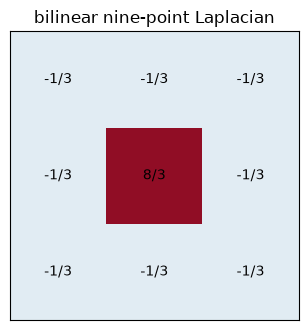

In [4]:
K = dense2(t_per)
centre = nid(2, 2)
stencil = np.zeros((3, 3))
for a, dx in enumerate((-1, 0, 1)):
    for b, dy in enumerate((-1, 0, 1)):
        stencil[a, b] = K[centre, nid((2 + dx) % N, (2 + dy) % N)]
print("nodal stencil (times 3):\n", 3 * stencil)

fig, ax = plt.subplots(figsize=(3.4, 3.4))
ax.imshow(stencil, cmap="RdBu_r", vmin=-3, vmax=3)
for a in range(3):
    for b in range(3):
        ax.text(b, a, f"{3*stencil[a,b]:.0f}/3", ha="center", va="center")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("bilinear nine-point Laplacian")
plt.tight_layout(); plt.show()

## 4. Boundary treatment by direction — and the $4/3$ trap

This is the section worth reading carefully.

The treatment is chosen **per direction** and applied to **both** factors in
that direction's slot:

$$\mathbf{K}_{2D} = \mathbf{K}_1^{(x)} \otimes \mathbf{M}_1^{(y)}
                  + \mathbf{M}_1^{(x)} \otimes \mathbf{K}_1^{(y)}.$$

Clamp the left and right edges, leave top and bottom free. Then $x$ is
essential and $y$ is free.

Two asymmetries follow, and only one of them is forgiving.

In [5]:
def lap_q4(N, periodic):
    """Direct bilinear Q4 Laplacian assembly."""
    Ke = np.array([[4, -1, -2, -1], [-1, 4, -1, -2],
                   [-2, -1, 4, -1], [-1, -2, -1, 4]], float) / 6
    A = np.zeros((N*N, N*N))
    ids = lambda a, b: (a % N) * N + (b % N)
    for ex in range(N if periodic else N - 1):
        for ey in range(N if periodic else N - 1):
            n = [ids(ex, ey), ids(ex+1, ey), ids(ex+1, ey+1), ids(ex, ey+1)]
            for a in range(4):
                for b in range(4): A[n[a], n[b]] += Ke[a, b]
    return A

direct_open = lap_q4(N, periodic=False)
assert np.allclose(dense2(K2D(per=True)), lap_q4(N, True))
assert np.allclose(dense2(K2D((True, True), (True, True))), direct_open)
print("periodic and fully-free forms match direct assembly.")

# clamp left and right: keep the interior columns of nodes
keep = [nid(ix, iy) for ix in (1, 2) for iy in range(N)]
ii = np.ix_(keep, keep)

right = dense2(K2D(xf=(False, False), yf=(True, True)))    # y free  <- correct
wrong = dense2(K2D(xf=(False, False), yf=(False, False)))  # y essential <- wrong

print(f"correct recipe, restricted : max|err| = "
      f"{np.abs(right[ii] - direct_open[ii]).max():.2e}")
print(f"essential forms in y slot  : max|err| = "
      f"{np.abs(wrong[ii] - direct_open[ii]).max():.4f}   <-- 4/3")
assert np.abs(right[ii] - direct_open[ii]).max() < 1e-13
assert abs(np.abs(wrong[ii] - direct_open[ii]).max() - 4/3) < 1e-12

periodic and fully-free forms match direct assembly.
correct recipe, restricted : max|err| = 2.22e-16
essential forms in y slot  : max|err| = 1.3333   <-- 4/3


**A constrained direction is indifferent.** The essential and free forms of a
1D factor differ only in the diagonal entries at the two end nodes, and in a
constrained direction those are exactly the rows the constraint deletes. So
either form gives the same restricted operator.

**A free direction is not.** Those boundary rows survive the solve, and their
diagonal must carry the halving. Substituting the essential forms there is the
$4/3$ error above.

In [6]:
# the constrained direction really is indifferent
alt = dense2(K2D(xf=(True, True), yf=(True, True)))   # free forms in x too
print("swap x to the free forms, restricted difference:",
      np.abs(alt[ii] - right[ii]).max())
assert np.allclose(alt[ii], right[ii])

# where the 4/3 actually lives
D = np.abs(wrong[ii] - direct_open[ii])
bad = np.argwhere(D > 1e-9)
rows = sorted({keep[i] for i, _ in bad})
print("\nrows that go wrong:", [(r // N, r % N) for r in rows])
print("all on the y-boundary (iy = 0 or 3):",
      all(r % N in (0, N-1) for r in rows))

swap x to the free forms, restricted difference: 4.440892098500626e-16

rows that go wrong: [(1, 0), (1, 3), (2, 0), (2, 3)]
all on the y-boundary (iy = 0 or 3): True


## 5. Term counts: a product, not a square

$L_{2D} = |\mathcal{B}_x|\,|\mathcal{B}_y|$. It is a *square* only when both
directions carry the same treatment, which is the case Appendix B tabulates
and the case that made the general rule easy to miss.

Clamping one edge only puts six unitaries in that direction — one more than
essential, one fewer than free, since only one reflection is needed.

In [7]:
cases = [("none (periodic)",     dict(per=True),  dict(per=True)),
         ("all four (essential)", {},              {}),
         ("none (traction-free)", dict(fl=1, fr=1), dict(fl=1, fr=1)),
         ("left and right",       {},              dict(fl=1, fr=1)),
         ("left only",            dict(fr=1),      dict(fl=1, fr=1))]

print(f"{'edges clamped':<22}{'|Bx|':>6}{'|By|':>6}{'L_2D':>7}{'alpha_2D':>10}")
for nm, xk, yk in cases:
    Kx = K1(**xk); Ky = K1(**yk)
    t  = K2D(xf=(xk.get('fl', False), xk.get('fr', False)),
             yf=(yk.get('fl', False), yk.get('fr', False)),
             per=xk.get('per', False))
    print(f"{nm:<22}{len(Kx):>6}{len(Ky):>6}{len(t):>7}{alpha(t):>10.4f}")
    assert len(t) == len(Kx) * len(Ky)
    assert abs(alpha(t) - 16/3) < 1e-12
print("\nL is the product of the basis sizes; alpha never moves.")

edges clamped           |Bx|  |By|   L_2D  alpha_2D
none (periodic)            3     3      9    5.3333
all four (essential)       5     5     25    5.3333
none (traction-free)       7     7     49    5.3333
left and right             5     7     35    5.3333
left only                  6     7     42    5.3333

L is the product of the basis sizes; alpha never moves.


## 6. The block encoding

Same recipe as in one dimension, now on $2m = 4$ system qubits. The essential
case has $L = 25$, so $a = 5$ ancilla and $\mathcal{U}$ is $2^9 = 512$ square.

In [8]:
def prep_unitary(c, n_anc):
    d = 2 ** n_anc; v = np.zeros(d)
    v[:len(c)] = np.sqrt(np.abs(c) / np.abs(c).sum())
    M = np.eye(d); M[:, 0] = v
    Q, R = np.linalg.qr(M)
    return Q * np.sign(np.diag(R))

def block_encoding(t):
    keys = list(t); c = np.array([t[k] for k in keys]); L = len(keys)
    na = max(1, int(np.ceil(np.log2(L)))); da, ds = 2 ** na, N * N
    P = prep_unitary(c, na)
    SEL = np.zeros((da * ds, da * ds))
    for k in range(da):
        if k < L:
            p, q = keys[k]; Uk = np.sign(c[k]) * np.kron(U[p], U[q])
        else:
            Uk = np.eye(ds)
        SEL[k*ds:(k+1)*ds, k*ds:(k+1)*ds] = Uk
    PI = np.kron(P, np.eye(ds))
    return PI.T @ SEL @ PI, na, ds

for nm, xk, yk in cases[:3]:
    t = K2D(xf=(xk.get('fl', False), xk.get('fr', False)),
            yf=(yk.get('fl', False), yk.get('fr', False)),
            per=xk.get('per', False))
    Ub, na, ds = block_encoding(t)
    err  = np.abs(Ub[:ds, :ds] - dense2(t) / alpha(t)).max()
    unit = np.abs(Ub @ Ub.T - np.eye(Ub.shape[0])).max()
    print(f"{nm:<22} L={len(t):3d} a={na} qubits={na+2*m} dim={Ub.shape[0]:4d} "
          f"|top-K/alpha|={err:.1e} |UU^T-I|={unit:.1e}")
    assert err < 1e-12 and unit < 1e-12

none (periodic)        L=  9 a=4 qubits=8 dim= 256 |top-K/alpha|=2.2e-16 |UU^T-I|=1.2e-15
all four (essential)   L= 25 a=5 qubits=9 dim= 512 |top-K/alpha|=3.3e-16 |UU^T-I|=1.6e-15
none (traction-free)   L= 49 a=6 qubits=10 dim=1024 |top-K/alpha|=3.3e-16 |UU^T-I|=2.2e-15


## 7. The edge load

For $\partial u / \partial n = g$ on the right edge, the consistent nodal load
is a one-hot vector in $x$ times a profile in $y$:

$$\mathbf{f}_\partial = g\,\mathbf{e}_{N-1} \otimes
   \tfrac12 (1, 2, 2, 1)^{\top}.$$

The halved end values are the corner nodes, which belong to one element edge
rather than two — the same accounting that halves the boundary diagonal in the
operator.

In [9]:
g = 1.0
prof = 0.5 * np.array([1.0, 2.0, 2.0, 1.0])
f_edge = g * np.kron(np.eye(N)[N-1], prof)
print("f_edge reshaped to the grid (rows = ix, cols = iy):\n",
      f_edge.reshape(N, N))

# direct check: constant flux g on an edge of 3 unit elements.
# Each element contributes g*h/2 to each of its two nodes.
direct = np.zeros(N)
for e in range(N - 1):
    direct[e:e+2] += 0.5 * g
print("\ndirect edge assembly :", direct)
print("profile in the formula:", prof)
assert np.allclose(direct, prof)
print("\nInterior edge nodes get twice what the corners get, because they "
      "belong to two element edges rather than one.")

f_edge reshaped to the grid (rows = ix, cols = iy):
 [[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 1.  1.  0.5]]

direct edge assembly : [0.5 1.  1.  0.5]
profile in the formula: [0.5 1.  1.  0.5]

Interior edge nodes get twice what the corners get, because they belong to two element edges rather than one.


## 8. Exercises

1. **Recover the square.** Show that when both directions carry the same
   treatment, $L_{2D} \in \{9, 25, 49\}$, and explain why merging is what
   prevents the count from being $2|\mathcal{B}_x||\mathcal{B}_y|$.

2. **One-sided both ways.** Clamp the left edge and the bottom edge only.
   Predict $|\mathcal{B}_x|$, $|\mathcal{B}_y|$ and $L_{2D}$ before running it.

3. **Break it deliberately.** In the mixed case, swap only $\mathbf{M}_1$ in
   the $y$ slot to the essential form and leave $\mathbf{K}_1$ free. Is the
   error still $4/3$? Which rows move?

4. **Scaling.** Rebuild at $m = 3, 4, 5$ and confirm that $L$ and $\alpha$ do
   not change, while the matrix dimension grows as $4^m$. This is the whole
   point of the construction.

5. **On to elasticity.** In Appendix C the same nine shift offsets carry three
   Pauli components instead of one, giving $17$ terms rather than $9$. Predict
   which offsets carry which component before opening that notebook.